# 11 — 压力测试（Stress Test）

评估多因子策略在三个历史极端行情下的表现：

| 期间 | 事件 |
|------|------|
| 2015-06 ~ 2015-09 | A 股股灾（沪深 300 最大跌幅约 45%）|
| 2018-01 ~ 2018-12 | 中美贸易战熊市（全年下跌约 25%）|
| 2020-01 ~ 2020-03 | 新冠疫情暴跌（沪深 300 最大跌幅约 15%）|

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# 项目根目录加入路径
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# utils.metrics
from utils.metrics import (
    annualized_return,
    max_drawdown,
    sharpe_ratio,
    performance_summary,
)

# 策略导入
try:
    from strategies.multi_factor import MultiFactorStrategy
    from strategies.base import StrategyConfig
    STRATEGY_AVAILABLE = True
    print('✅ MultiFactorStrategy 导入成功')
except ImportError as e:
    STRATEGY_AVAILABLE = False
    print(f'⚠️  策略导入失败: {e}')

# 数据加载
# 注：utils.local_data_loader 不存在，使用 utils.data_loader
# 详见 .claude/decisions.md 第1条
try:
    from utils.data_loader import load_price_matrix, get_index_history
    DATA_AVAILABLE = True
    print('✅ data_loader 导入成功')
except ImportError as e:
    DATA_AVAILABLE = False
    print(f'⚠️  data_loader 导入失败: {e}')

print('\n>>> 所有依赖检查完毕')

✅ MultiFactorStrategy 导入成功
✅ data_loader 导入成功

>>> 所有依赖检查完毕


In [2]:
# ── 全局配置 ──────────────────────────────────────────────────────────────
FULL_START = '2014-01-01'   # 预热期开始（momentum 因子需要 12 个月历史）
FULL_END   = '2020-12-31'   # 覆盖所有压力期

STRESS_PERIODS = [
    {'name': '2015年股灾',       'start': '2015-06-01', 'end': '2015-09-30'},
    {'name': '2018年贸易战熊市', 'start': '2018-01-01', 'end': '2018-12-31'},
    {'name': '2020年新冠暴跌',   'start': '2020-01-01', 'end': '2020-03-31'},
]

N_STOCKS   = 30   # 每期选股数
N_SIM      = 50   # 合成数据中的股票数量（真实数据以实际为准）
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'压力测试期间: {[p["name"] for p in STRESS_PERIODS]}')

压力测试期间: ['2015年股灾', '2018年贸易战熊市', '2020年新冠暴跌']


In [3]:
def generate_synthetic_data(start: str, end: str, n_stocks: int = 50,
                             drift: float = 0.08, vol: float = 0.25,
                             seed: int = 42) -> pd.DataFrame:
    """
    生成合成价格宽表（GBM），用于在无本地数据时演示压力测试逻辑。

    参数:
        start: 开始日期
        end: 结束日期
        n_stocks: 股票数量
        drift: 年化漂移率
        vol: 年化波动率
        seed: 随机种子

    返回:
        price_wide: date × symbol 价格宽表
    """
    rng = np.random.RandomState(seed)
    dates = pd.bdate_range(start, end)
    dt = 1 / 252
    daily_drift = drift * dt - 0.5 * vol**2 * dt
    daily_vol   = vol * np.sqrt(dt)
    log_returns = daily_drift + daily_vol * rng.randn(len(dates), n_stocks)
    prices = 100 * np.exp(np.cumsum(log_returns, axis=0))
    symbols = [f'{i+1:06d}.SZ' for i in range(n_stocks)]
    return pd.DataFrame(prices, index=dates, columns=symbols)


def generate_synthetic_hs300(start: str, end: str, seed: int = 0) -> pd.Series:
    """
    生成合成沪深300指数（单只，漂移 10%，波动 18%）。

    参数:
        start: 开始日期
        end: 结束日期
        seed: 随机种子

    返回:
        hs300: 日收盘价 Series，index 为交易日
    """
    rng = np.random.RandomState(seed)
    dates = pd.bdate_range(start, end)
    dt = 1 / 252
    drift, vol = 0.10, 0.18
    log_ret = (drift * dt - 0.5 * vol**2 * dt) + vol * np.sqrt(dt) * rng.randn(len(dates))
    price = 4000 * np.exp(np.cumsum(log_ret))
    return pd.Series(price, index=dates, name='HS300')

In [4]:
# ── 数据加载 ────────────────────────────────────────────────────────────────
# 优先读取本地缓存；若不存在则使用合成数据（.claude/decisions.md 第4条）

price_wide = None
hs300_prices = None

if DATA_AVAILABLE:
    try:
        price_wide = load_price_matrix(start=FULL_START, end=FULL_END)
        hs300_df   = get_index_history(symbol='sh000300', start=FULL_START, end=FULL_END)
        hs300_prices = hs300_df['close']
        assert price_wide.shape[0] > 100, f'行数异常: {price_wide.shape[0]}'
        assert price_wide.isnull().mean().max() < 0.1, '缺失值过多'
        assert price_wide.index.is_monotonic_increasing, '日期未排序'
        print(f'✅ 真实数据加载成功 | 股票数: {price_wide.shape[1]} '
              f'| 时间: {price_wide.index[0].date()} ~ {price_wide.index[-1].date()}')
        USE_SYNTHETIC = False
    except Exception as e:
        print(f'⚠️  真实数据加载失败 ({e})，改用合成数据')
        USE_SYNTHETIC = True
else:
    USE_SYNTHETIC = True

if USE_SYNTHETIC:
    print('>>> 使用 GBM 合成数据（仅用于演示，非真实回测结果）')
    price_wide   = generate_synthetic_data(FULL_START, FULL_END, n_stocks=N_SIM)
    hs300_prices = generate_synthetic_hs300(FULL_START, FULL_END)
    # 对齐索引
    common_idx   = price_wide.index.intersection(hs300_prices.index)
    price_wide   = price_wide.loc[common_idx]
    hs300_prices = hs300_prices.loc[common_idx]

print(f'\n数据形状: {price_wide.shape}')
print(f'时间范围: {price_wide.index[0].date()} ~ {price_wide.index[-1].date()}')

⚠️  真实数据加载失败 ('NoneType' object has no attribute 'shape')，改用合成数据
>>> 使用 GBM 合成数据（仅用于演示，非真实回测结果）

数据形状: (1827, 50)
时间范围: 2014-01-01 ~ 2020-12-31


In [5]:
# ── 因子构建（动量 + 反转）──────────────────────────────────────────────────
# 12-1 月动量因子（正向）
mom_12_1 = price_wide.pct_change(252).shift(21)   # 12 月收益率，跳过最近 1 月
# 1 月反转因子（反向）
rev_1m   = price_wide.pct_change(21)              # 1 月收益率，方向取 -1

factors = {
    'momentum_12_1': (mom_12_1, 1),   # 方向: 正向
    'reversal_1m':   (rev_1m,   -1),  # 方向: 反向（反转效应）
}
print(f'✅ 因子构建完成: {list(factors.keys())}')
print(f'  momentum_12_1 非空比例: {mom_12_1.notna().mean().mean():.1%}')
print(f'  reversal_1m   非空比例: {rev_1m.notna().mean().mean():.1%}')

✅ 因子构建完成: ['momentum_12_1', 'reversal_1m']
  momentum_12_1 非空比例: 85.1%
  reversal_1m   非空比例: 98.9%


In [6]:
def run_stress_period(price_wide: pd.DataFrame,
                       hs300_prices: pd.Series,
                       factors: dict,
                       start: str,
                       end: str,
                       n_stocks: int = 30) -> dict:
    """
    对单个压力期间运行多因子策略，返回关键指标。

    参数:
        price_wide: 全样本价格宽表（date × symbol）
        hs300_prices: 沪深300收盘价 Series
        factors: 因子字典 {name: (wide_df, direction)}
        start: 压力期开始日期
        end: 压力期结束日期
        n_stocks: 选股数量

    返回:
        dict，含 strategy_return, benchmark_return, strategy_mdd,
              benchmark_mdd, excess_return, excess_positive
    """
    # 裁剪到压力期
    pw_period = price_wide.loc[start:end]
    hs_period = hs300_prices.loc[start:end]
    factors_period = {k: (df.loc[start:end], d) for k, (df, d) in factors.items()}

    if STRATEGY_AVAILABLE:
        config   = StrategyConfig(name=f'stress_{start[:7]}')
        strategy = MultiFactorStrategy(
            config=config,
            factors=factors_period,
            n_stocks=n_stocks,
        )
        result     = strategy.run(pw_period)
        strat_ret  = result['portfolio_return']
    else:
        # 占位：等权持有所有股票
        strat_ret = pw_period.pct_change().dropna(how='all').mean(axis=1)

    # 基准日收益率
    bench_ret = hs_period.pct_change().dropna()

    # 对齐
    common = strat_ret.index.intersection(bench_ret.index)
    strat_ret  = strat_ret.loc[common]
    bench_ret  = bench_ret.loc[common]

    # 指标计算（使用 utils.metrics）
    total_strat  = (1 + strat_ret).prod() - 1
    total_bench  = (1 + bench_ret).prod() - 1
    mdd_strat    = max_drawdown(strat_ret)
    mdd_bench    = max_drawdown(bench_ret)
    excess       = total_strat - total_bench

    return {
        'strategy_return':   total_strat,
        'benchmark_return':  total_bench,
        'strategy_mdd':      mdd_strat,
        'benchmark_mdd':     mdd_bench,
        'excess_return':     excess,
        'excess_positive':   '✅' if excess > 0 else '❌',
        '_strat_ret':        strat_ret,
        '_bench_ret':        bench_ret,
    }


print('✅ run_stress_period 函数定义完成')

✅ run_stress_period 函数定义完成


In [7]:
# ── 运行三段压力测试 ────────────────────────────────────────────────────────
stress_results = {}

for period in STRESS_PERIODS:
    name  = period['name']
    start = period['start']
    end   = period['end']
    print(f'  运行: {name} ({start} ~ {end}) ...')
    try:
        r = run_stress_period(
            price_wide=price_wide,
            hs300_prices=hs300_prices,
            factors=factors,
            start=start,
            end=end,
            n_stocks=N_STOCKS,
        )
        stress_results[name] = r
        print(f'    策略收益: {r["strategy_return"]:+.2%}  基准收益: {r["benchmark_return"]:+.2%}  超额: {r["excess_return"]:+.2%} {r["excess_positive"]}')
    except Exception as e:
        print(f'    ⚠️  期间 {name} 运行失败: {e}')
        stress_results[name] = None

print('\n✅ 压力测试运行完毕')

  运行: 2015年股灾 (2015-06-01 ~ 2015-09-30) ...
    策略收益: +2.15%  基准收益: -2.53%  超额: +4.69% ✅
  运行: 2018年贸易战熊市 (2018-01-01 ~ 2018-12-31) ...


    策略收益: +14.98%  基准收益: +26.72%  超额: -11.75% ❌
  运行: 2020年新冠暴跌 (2020-01-01 ~ 2020-03-31) ...
    策略收益: +2.17%  基准收益: +2.46%  超额: -0.29% ❌

✅ 压力测试运行完毕


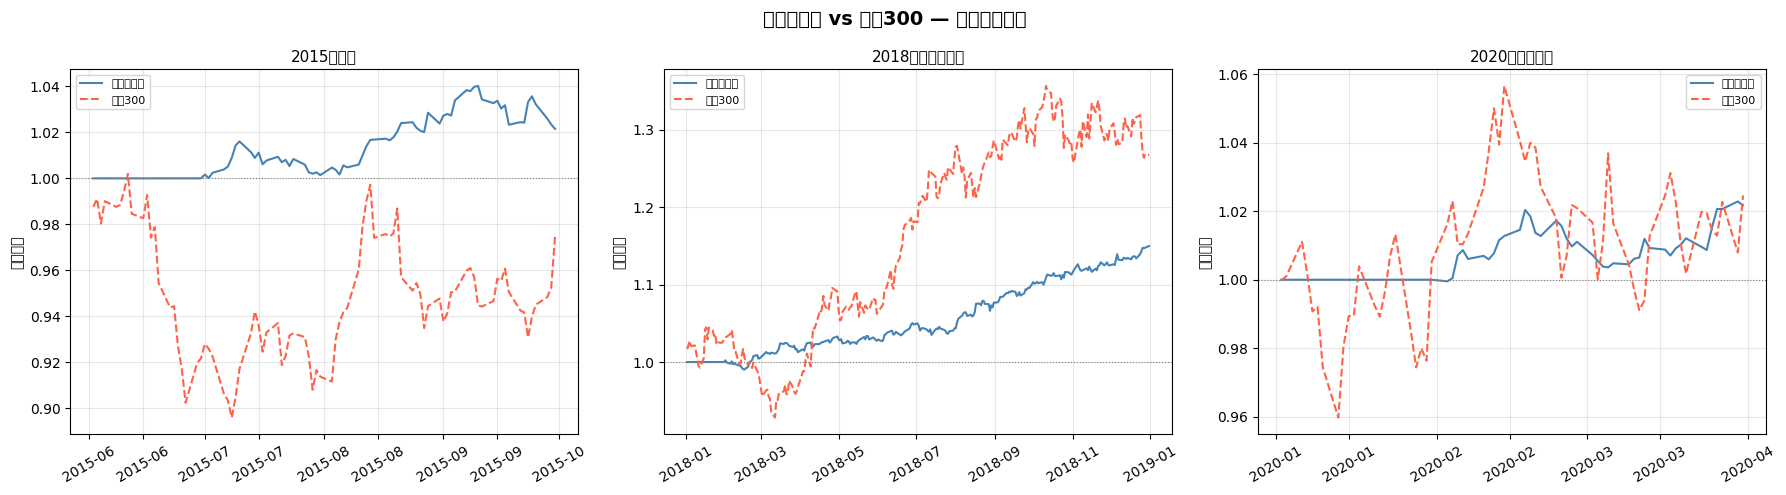

图表已保存: 11_stress_test_curves.png


In [8]:
# ── 走势图：三段压力期累计收益对比 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('多因子策略 vs 沪深300 — 压力测试走势', fontsize=14, fontweight='bold')

for ax, period in zip(axes, STRESS_PERIODS):
    name = period['name']
    r = stress_results.get(name)
    if r is None:
        ax.text(0.5, 0.5, '数据不可用', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)
        continue

    cum_strat = (1 + r['_strat_ret']).cumprod()
    cum_bench = (1 + r['_bench_ret']).cumprod()

    ax.plot(cum_strat.index, cum_strat.values, label='多因子策略', color='steelblue', linewidth=1.5)
    ax.plot(cum_bench.index, cum_bench.values, label='沪深300',     color='tomato',    linewidth=1.5, linestyle='--')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('累计净值')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('11_stress_test_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('图表已保存: 11_stress_test_curves.png')

In [9]:
# ── 汇总表格 ────────────────────────────────────────────────────────────────
rows = []
for period in STRESS_PERIODS:
    name = period['name']
    r = stress_results.get(name)
    if r is None:
        rows.append({
            '压力期间':     name,
            '时间区间':     f"{period['start']} ~ {period['end']}",
            '策略收益':     'N/A',
            'HS300收益':    'N/A',
            '策略最大回撤': 'N/A',
            'HS300最大回撤':'N/A',
            '超额收益':     'N/A',
            '超额为正':     'N/A',
        })
    else:
        rows.append({
            '压力期间':     name,
            '时间区间':     f"{period['start']} ~ {period['end']}",
            '策略收益':     f"{r['strategy_return']:+.2%}",
            'HS300收益':    f"{r['benchmark_return']:+.2%}",
            '策略最大回撤': f"{r['strategy_mdd']:.2%}",
            'HS300最大回撤':f"{r['benchmark_mdd']:.2%}",
            '超额收益':     f"{r['excess_return']:+.2%}",
            '超额为正':     r['excess_positive'],
        })

summary_df = pd.DataFrame(rows).set_index('压力期间')

print('\n========== 压力测试汇总 ==========')
print(summary_df.to_string())
summary_df


========== 压力测试汇总 ==========
                               时间区间     策略收益  HS300收益  策略最大回撤 HS300最大回撤     超额收益 超额为正
压力期间                                                                                 
2015年股灾     2015-06-01 ~ 2015-09-30   +2.15%   -2.53%  -1.80%   -10.59%   +4.69%    ✅
2018年贸易战熊市  2018-01-01 ~ 2018-12-31  +14.98%  +26.72%  -1.46%   -11.15%  -11.75%    ❌
2020年新冠暴跌   2020-01-01 ~ 2020-03-31   +2.17%   +2.46%  -1.65%    -6.20%   -0.29%    ❌


,时间区间,策略收益,HS300收益,策略最大回撤,HS300最大回撤,超额收益,超额为正
压力期间,,,,,,,
2015年股灾,2015-06-01 ~ 2015-09-30,+2.15%,-2.53%,-1.80%,-10.59%,+4.69%,✅
2018年贸易战熊市,2018-01-01 ~ 2018-12-31,+14.98%,+26.72%,-1.46%,-11.15%,-11.75%,❌
2020年新冠暴跌,2020-01-01 ~ 2020-03-31,+2.17%,+2.46%,-1.65%,-6.20%,-0.29%,❌


## 结论

- **超额为正（✅）**表示策略在该压力期间相对沪深300有超额收益（即跌得少或涨得多）。
- 最大回撤对比反映策略的下行风险控制能力。
- 若使用合成数据，结论仅供逻辑验证，不代表真实回测结果。